In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the taxis dataset
df = sns.load_dataset("taxis")

In [3]:
# Show first 5 rows
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

In [4]:
# Check missing values
print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [5]:
# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [30]:
# Check missing values before cleaning
print(df.isnull().sum())

# Fill missing values
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])

df["pickup_zone"] = df["pickup_zone"].fillna(df["pickup_zone"].mode()[0])

df["dropoff_zone"] = df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])

df["pickup_borough"] = df["pickup_borough"].fillna(df["pickup_borough"].mode()[0])

df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])

# Check missing values after cleaning
print("\nAfter Filling Missing Values")

print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

After Filling Missing Values
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


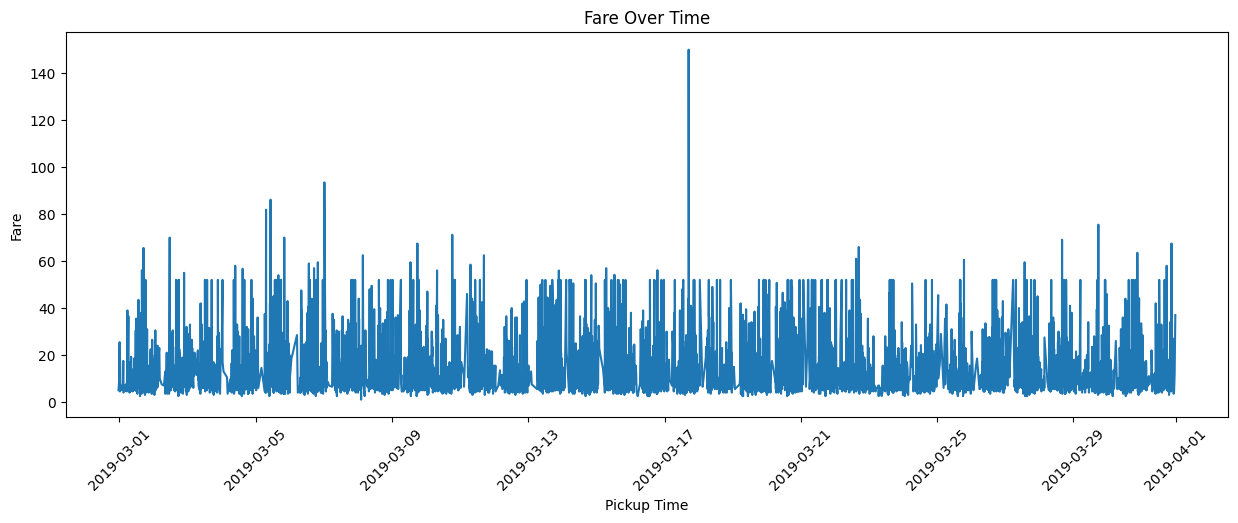

In [68]:
# ---------------- LINE CHART ----------------
plt.figure(figsize=(15,5))

plt.plot(df["pickup"], df["fare"])
plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.xticks(rotation=45)
plt.show()

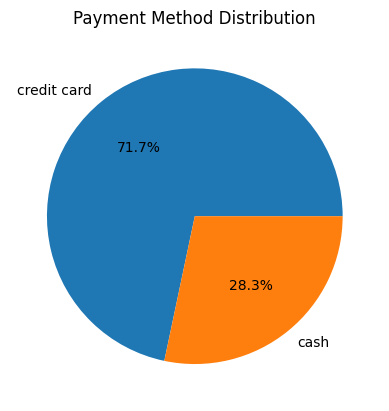

In [13]:
# ---------------- PIE CHART ----------------

payment_count = df["payment"].value_counts()

plt.pie(payment_count,
        labels=payment_count.index,
        autopct="%1.1f%%")

plt.title("Payment Method Distribution")

plt.show()

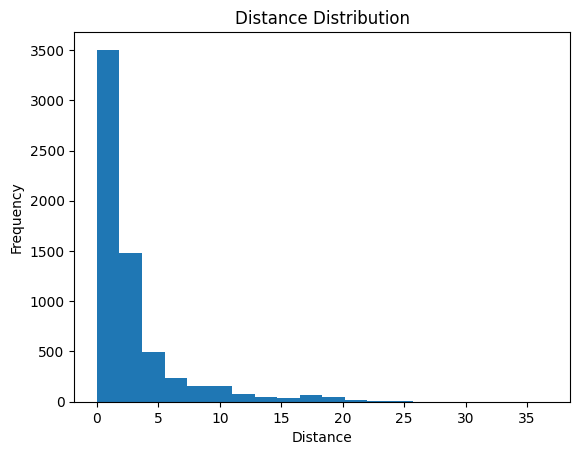

In [16]:
# ---------------- HISTOGRAM ----------------

plt.hist(df["distance"], bins=20)

plt.title("Distance Distribution")

plt.xlabel("Distance")

plt.ylabel("Frequency")

plt.show()

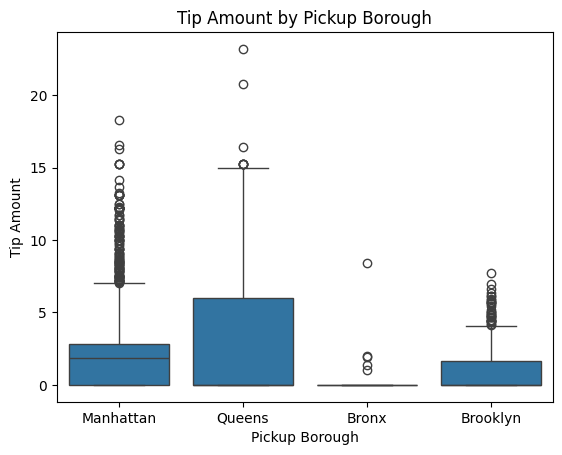

In [17]:
# ---------------- BOX PLOT ----------------

sns.boxplot(x="pickup_borough",
            y="tip",
            data=df)

plt.title("Tip Amount by Pickup Borough")

plt.xlabel("Pickup Borough")

plt.ylabel("Tip Amount")

plt.show()

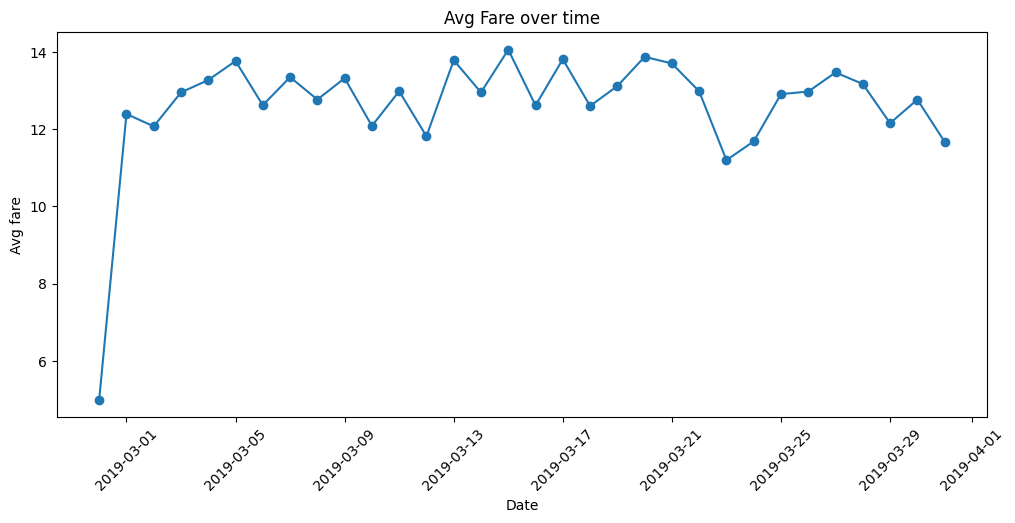

In [18]:
#visualization
#converting pickup column to datetime data type

df['pickup']=pd.to_datetime(df['pickup'])
df_sorted=df.sort_values('pickup')

df_sorted['pickup_date']=df_sorted['pickup'].dt.date

grouped_datefare=df_sorted.groupby('pickup_date')['fare'].mean()

#Line chart
plt.figure(figsize=(12,5))
plt.plot(grouped_datefare.index,grouped_datefare.values, marker='o')
plt.title("Avg Fare over time")
plt.xlabel('Date')
plt.ylabel('Avg fare')

plt.xticks(rotation=45)

plt.show()

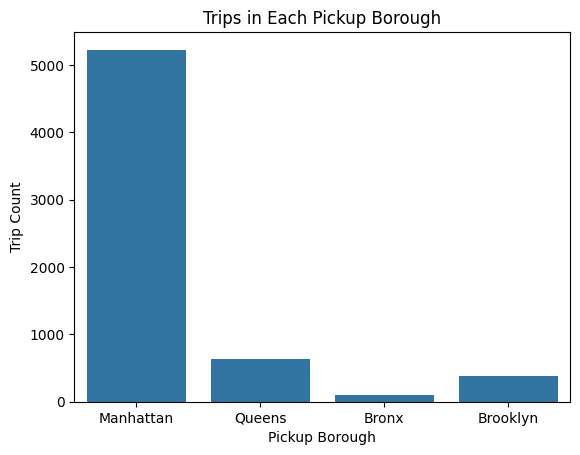

In [40]:
# ---------------- COUNT PLOT ----------------

sns.countplot(x="pickup_borough", data=df)

plt.title("Trips in Each Pickup Borough")

plt.xlabel("Pickup Borough")

plt.ylabel("Trip Count")

plt.show()

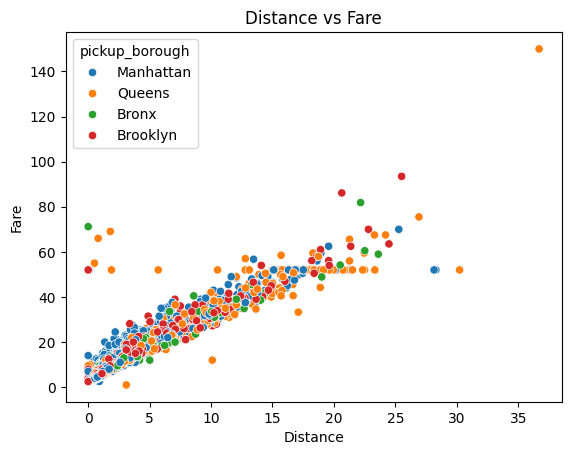

In [35]:
# ---------------- SCATTER PLOT ----------------

sns.scatterplot(x="distance",
                y="fare",
                hue="pickup_borough",
                data=df)

plt.title("Distance vs Fare")

plt.xlabel("Distance")

plt.ylabel("Fare")

plt.show()

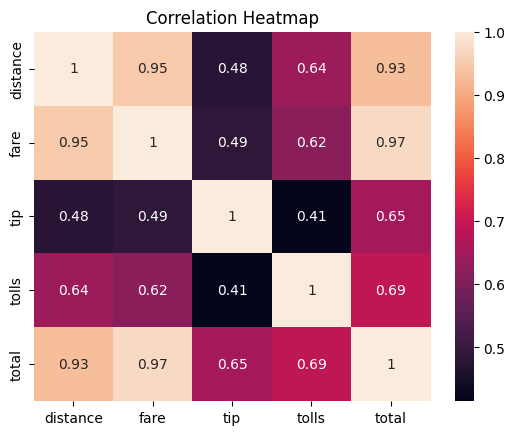

In [36]:
# ---------------- HEATMAP ----------------

# Select numerical columns
num_data = df[["distance", "fare", "tip", "tolls", "total"]]

# Find correlation
corr = num_data.corr()

# Create heatmap
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

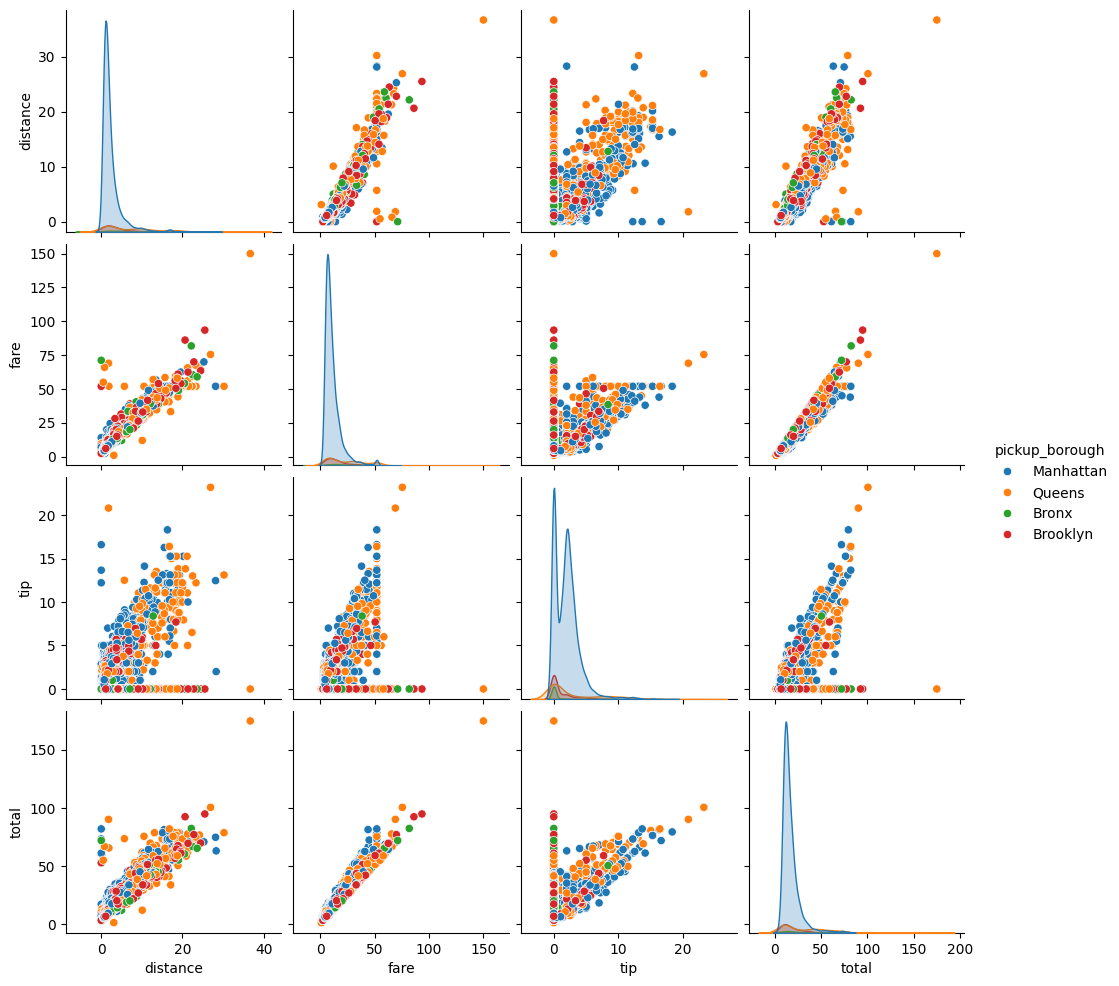

In [39]:
# Pair Plot

sns.pairplot(df[["distance",
                 "fare",
                 "tip",
                 "total",
                 "pickup_borough"]],
             hue="pickup_borough")

plt.show()

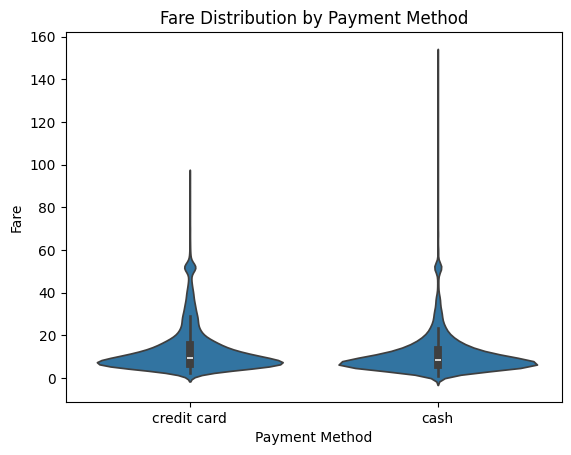

In [38]:
# ---------------- VIOLIN PLOT ----------------

sns.violinplot(x="payment",
               y="fare",
               data=df)

plt.title("Fare Distribution by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Fare")

plt.show()